In [24]:
import numpy as np
import pandas as pd
import seaborn as sns

import torch

In [34]:
DATA_DIR = '../data/'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [35]:
dataset = pd.read_csv(DATA_DIR + 'text_dataset.csv', encoding='utf-8')
dataset.head()

,id,timestamp,text
0,0,1712998082,А зач
1,1,1712998089,Есть же петрушка
2,2,1712998092,Ну в овсеми
3,3,1712998095,Там не все
4,4,1712998108,Ааа


In [36]:
dataset['next_text'] = dataset['text'].shift(-1)
dataset['delta_time'] = - dataset['timestamp'] + dataset['timestamp'].shift(-1)
dataset

,id,timestamp,text,next_text,delta_time
0,0,1712998082,А зач,Есть же петрушка,7.0
1,1,1712998089,Есть же петрушка,Ну в овсеми,3.0
2,2,1712998092,Ну в овсеми,Там не все,3.0
3,3,1712998095,Там не все,Ааа,13.0
4,4,1712998108,Ааа,Типа ещё сииимёёён,8.0
...,...,...,...,...,...
151993,151993,1787512789,посмотрим,как же там идет экспорт сообщений,266.0
151994,151994,1787513055,как же там идет экспорт сообщений,полчаса,2.0
151995,151995,1787513057,полчаса,NaN,7.0
151996,151996,1787513064,NaN,мегапон,5.0


In [37]:
dataset.dropna(inplace=True)
dataset.__len__()

128642

<Axes: xlabel='delta_time', ylabel='Count'>

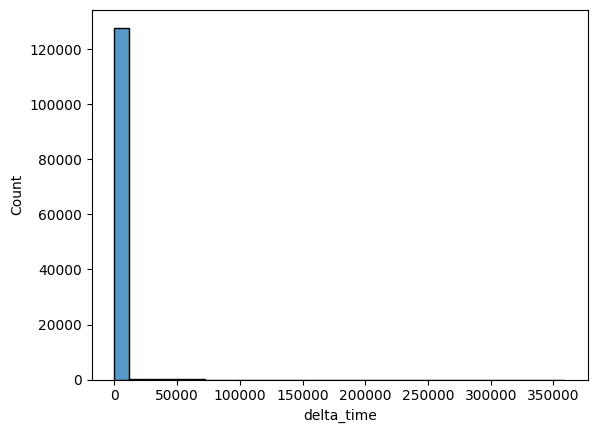

In [38]:
sns.histplot(dataset['delta_time'], bins=30)

<Axes: xlabel='delta_time', ylabel='Count'>

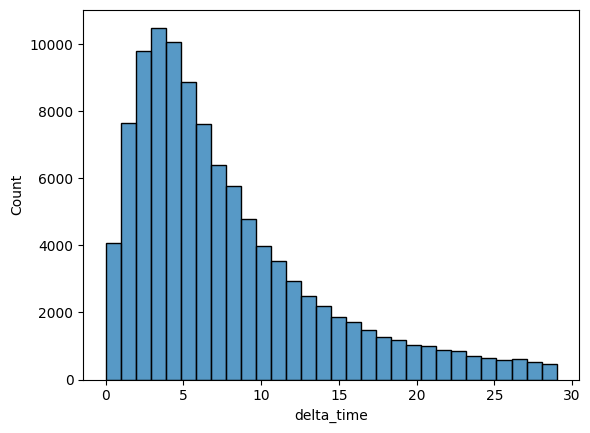

In [40]:
dt = dataset['delta_time']
dataset = dataset[dt < 30]
sns.histplot(dataset['delta_time'], bins=30)

In [42]:
dataset.__len__()

105469